In [2]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import re
import joblib

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import sent_tokenize, word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sungj\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [19]:
def load_shuffle_csv(path):
    new_df = pd.read_csv(path)
    new_df = shuffle(new_df, random_state=42).reset_index(drop=True)
    return new_df

In [20]:
def clean_hos_df(new_df):
    new_df["text"] = new_df["text"].str.replace(r"[^a-zA-Z0-9$'\s ]", "", regex=True)
    new_df["text"] = new_df["text"].str.replace(r"<.*?>", "", regex=True)
    new_df.loc[new_df["Neutral"] == 1, "Neutral"] = 1
    new_df.loc[new_df["Negative"] == 1, "Negative"] = 0
    new_df.loc[new_df["Positive"] == 1 ,"Positive"] = 2
    new_df["sentiment"] = new_df["Negative"] + new_df["Positive"] + new_df["Neutral"]
    new_df = new_df.drop(columns=["Negative", "Positive", "Neutral"])

    index = new_df[new_df["text"].isna()].index
    new_df = new_df.drop(index=index).reset_index(drop=True)

    index = new_df[new_df["sentiment"].isna()].index
    new_df = new_df.drop(index=index).reset_index(drop=True)

    return new_df

In [21]:
def encode_sentiment(new_df):
    new_df.loc[new_df["sentiment"] == "Negative", "sentiment"] = '0'
    new_df.loc[new_df["sentiment"] == "Neutral", "sentiment"] = '1'
    new_df.loc[new_df["sentiment"] == "Positive", "sentiment"] = '2'
    new_df["sentiment"] = new_df["sentiment"].astype('int').astype("category")
    return new_df

In [22]:
hos_df = load_shuffle_csv("hos_sentiment.csv")
hos_df = clean_hos_df(hos_df)
emotion_df = load_shuffle_csv("emotion_sentiment.csv")
social_media_df = load_shuffle_csv("social_media_sentiment.csv")
hotel_df = load_shuffle_csv("hotel_sentiment.csv")

In [23]:
hos_df = hos_df.dropna().reset_index(drop=True)
emotion_df = emotion_df.dropna().reset_index(drop=True)
social_media_df = social_media_df.dropna().reset_index(drop=True)
emotion_df = encode_sentiment(emotion_df)
social_media_df = encode_sentiment(social_media_df)

emotion_df["sentiment"] = emotion_df["sentiment"].astype('int').astype("category")
social_media_df["sentiment"] = social_media_df["sentiment"].astype('int').astype("category")


In [24]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

In [6]:
stop_words = set(stopwords.words("english"))
stop_words -= {"no", "nor", "not", "never",
    "none", "nothing", "nobody", "neither"}

def tokenize_text(new_df):
    new_df["text"] = new_df["text"].astype('string')

    processed_list = []
    bad_idx = []
    for idx, sentence in enumerate(new_df['text']):
        if sentence:
            words = word_tokenize(sentence)
            filtered_words = [word for word in words if word.lower() not in stop_words]

            tokens = [t for t in filtered_words if t.isalpha()]

            filtered_tokens = [t for t in tokens if t not in stop_words]

            tagged = nltk.pos_tag(filtered_tokens)

            lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

            text = " ".join(lemmatized)
            if text.strip() == "":
                bad_idx.append(idx)
            else:
                processed_list.append(text)
        else:
            bad_idx.append(idx)
    new_df = new_df.drop(index=bad_idx).reset_index(drop=True)

    new_df.insert(1,"processed_text", processed_list)
    new_df = new_df.drop(columns=["text"])
    return new_df

In [26]:
#I all ready did this stuff
# hotel_df = shuffle(hotel_df).reset_index(drop=True)
# neg_df = hotel_df["Negative_Review"].to_frame()
# pos_df = hotel_df["Positive_Review"].to_frame()
# neg_df["sentiment"] = 0
# neg_df.rename(columns={"Negative_Review": "text"}, inplace=True)
# pos_df["sentiment"] = 2
# pos_df.rename(columns={"Positive_Review": "text"},inplace=True)
# hotel_df = pd.concat((neg_df, pos_df), axis=0).reset_index(drop=True)

hotel_df = hotel_df.dropna().reset_index(drop=True)
hotel_df.to_csv("hotel_sentiment.csv", index=False)
repair_df = pd.read_csv("home_repair_sentiment_10k.csv")
neutral_df = pd.read_csv("neutral_sentiment.csv")
negation_df = pd.read_csv("negation_examples.csv")
negation_df["sentiment"] = negation_df["sentiment"].astype('int').astype("category")


In [30]:
df = pd.concat([hos_df, emotion_df, social_media_df, hotel_df, repair_df, neutral_df, negation_df], axis=0).reset_index(drop=True)
df["text"] = df["text"].str.lower().str.strip()
df.drop(index=df[df["text"].isna()].index).reset_index(drop=True)
df.to_csv("unprocessed_sentiment_data.csv", index=False)
processed_df = tokenize_text(df)
processed_df.to_csv("processed_sentiment_data.csv", index=False)

In [16]:
p_df = pd.read_csv("unprocessed_sentiment_data.csv")
p_df.drop(index=p_df[p_df["text"].isna()].index).to_csv("unprocessed_sentiment_data.csv", index=False)

In [18]:
total_df = pd.read_csv("processed_sentiment_data.csv")
X, y = total_df["processed_text"], total_df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Did a gridsearch on the Pipeline and got these values as the best.
#params = { 'logreg__C': [1, 2, 3], }
#https://zekehochberg.github.io/pipeline-and-gridsearch/ this was helpful to learn how to use GridSearchCV on a pipeline

In [26]:
#I ran it many times and did the gridsearch. These were the results that were best.
pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                ngram_range=(1, 3),
                stop_words=list(stop_words),
                min_df=.00006,
                max_df=.85
            )),
            ('logreg', LogisticRegression(
                solver='lbfgs',
                C=1.5,
                max_iter=300
            ))
        ])

# grid = GridSearchCV(pipeline, params, cv=3, scoring="accuracy")

pipe.fit(X_train, y_train)
# est = grid.best_estimator_
y_pred = pipe.predict(X_test)
print(f"Testing Acc: {accuracy_score(y_test, y_pred)}")
print(f"Training Acc: {accuracy_score(y_train, pipe.predict(X_train))}")
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))

Testing Acc: 0.9177816725801166
Training Acc: 0.9384424661487
              precision    recall  f1-score   support

    Negative       0.90      0.94      0.92     29384
     Neutral       0.91      0.75      0.82      8498
    Positive       0.93      0.94      0.94     32297

    accuracy                           0.92     70179
   macro avg       0.92      0.88      0.89     70179
weighted avg       0.92      0.92      0.92     70179



In [27]:
joblib.dump(pipe, "tfidf_logreg_model.pkl")

['tfidf_logreg_model.pkl']

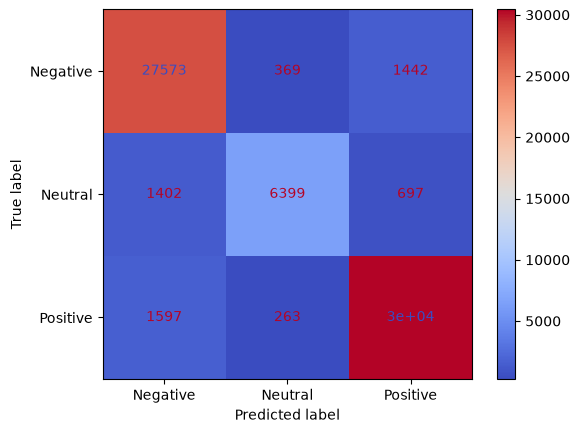

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Neutral", "Positive"])
cmd.plot(cmap="coolwarm")

In [18]:
from logreg_class import LogRegTfidfModel
logreg_model = LogRegTfidfModel()
logreg_model.predict("the house has a window")
logreg_model.print_prediction()

** LogReg-Tfidf Model **
Predicted Sentiment: Negative
Confidence: %60.67


In [9]:
from finetuned_roberta_class import FTRobertaModel
ft_roberta_model = FTRobertaModel()
ft_roberta_model.predict("The house's quality was good")
ft_roberta_model.print_prediction()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1893.30it/s]



** Roberta Model **
Predicted Sentiment: Positive
Confidence: %82.35
